### Project 1: BRFSS Mental Health Analysis
#### Notebook 05: Classification Modeling
**Author:** Amanda Shero  
**Date:** April 2026  
**Description:** Classification modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [3]:
df = pd.read_csv('df_encoded.csv')
df.shape

(425215, 45)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425215 entries, 0 to 425214
Data columns (total 45 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   _AGEG5YR         425215 non-null  float64
 1   SEXVAR           425215 non-null  float64
 2   EDUCA            425215 non-null  float64
 3   INCOME3          425215 non-null  float64
 4   _URBSTAT         425215 non-null  float64
 5   GENHLTH          425215 non-null  float64
 6   PHYSHLTH         425215 non-null  float64
 7   ADDEPEV3         425215 non-null  float64
 8   CVDINFR4         425215 non-null  float64
 9   ASTHMA3          425215 non-null  float64
 10  HAVARTH4         425215 non-null  float64
 11  CHCCOPD3         425215 non-null  float64
 12  EXERANY2         425215 non-null  float64
 13  SMOKDAY2         425215 non-null  float64
 14  AVEDRNK3         425215 non-null  float64
 15  DRNK3GE5         425215 non-null  float64
 16  _HLTHPL1         425215 non-null  float64
 17  ME

In [ ]:
# Target variable for classification
y_classification = df['MENT14D_binary']

In [ ]:
# Feature matrices for classification
X_A = df.drop(['MENTHLTH',  '_MENT14D', 'MENT14D_binary'], axis=1)
X_B = df.drop(['MENTHLTH',  '_MENT14D', 'MENT14D_binary', 'ADDEPEV3'], axis=1)

print(X_A.shape)
print(X_B.shape)

(425215, 42)
(425215, 41)


Model A — includes ADDEPEV3 (depression diagnosis) + all other predictors

Model B — excludes ADDEPEV3, predicts mental distress from sociodemographic and behavioral factors only

In [10]:
X_A_train, X_A_test, y_A_train, y_A_test = train_test_split(X_A, y_classification, test_size=0.2, random_state=42, stratify=y_classification)
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(X_B, y_classification, test_size=0.2, random_state=42, stratify=y_classification)

print(X_A_train.shape, X_A_test.shape)
print(X_B_train.shape, X_B_test.shape)

(340172, 42) (85043, 42)
(340172, 41) (85043, 41)


In [33]:
# Logistic Regression Model A / includes depression diagnosis

# Instantiate
lg_A = LogisticRegression(max_iter=1000)
# convergence warning at 100 iterations

# Fit
lg_A.fit(X_A_train, y_A_train)

# Predict
y_A_pred_lg = lg_A.predict(X_A_test)

print(classification_report(y_A_test, y_A_pred))

              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93     73429
         1.0       0.64      0.30      0.41     11614

    accuracy                           0.88     85043
   macro avg       0.77      0.63      0.67     85043
weighted avg       0.86      0.88      0.86     85043



Class 0 (no frequent distress):
* Precision 0.90, Recall 0.97 - the model is excellent at identifying people without frequent distress

Class 1 (frequent distress):
* Precision 0.64; Recall 0.30 - when the model predicts frequent distress, it's right about 64% of the time BUT it only catches about 30% of the people who actually have frequent distress (so the model is missing ~70% of the people that have frequent mental distress)

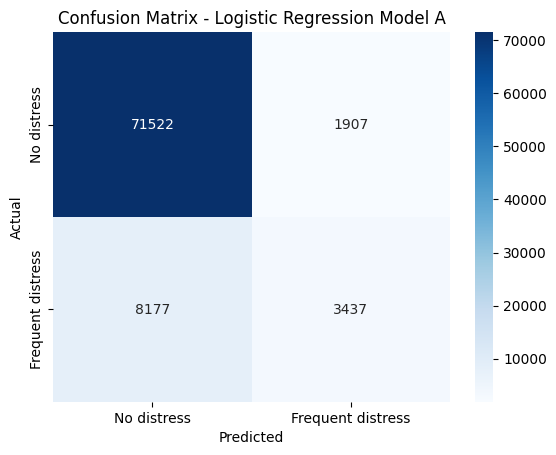

In [25]:
cm = confusion_matrix(y_A_test, y_A_pred_lg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No distress', 'Frequent distress'],
            yticklabels=['No distress', 'Frequent distress'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression Model A')
plt.show()

* True Negatives: 71,522 — correctly predicted no distress 
* False Positives: 1,907 — predicted distress but actually fine
* False Negatives: 8,177 — predicted no distress but actually had frequent distress
* True Positives: 3,437 — correctly identified frequent distress 

In [34]:
lg_A_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lg_A_balanced.fit(X_A_train, y_A_train)
y_A_pred_balanced_lg = lg_A_balanced.predict(X_A_test)
print(classification_report(y_A_test, y_A_pred_balanced_lg))

              precision    recall  f1-score   support

         0.0       0.95      0.79      0.86     73429
         1.0       0.35      0.73      0.48     11614

    accuracy                           0.78     85043
   macro avg       0.65      0.76      0.67     85043
weighted avg       0.87      0.78      0.81     85043



In [28]:
print('AUC-ROC Model A (original):', roc_auc_score(y_A_test, y_A_pred_lg))
print('AUC-ROC Model A (balanced):', roc_auc_score(y_A_test, y_A_pred_balanced_lg))

AUC-ROC Model A (original): 0.63498263692132
AUC-ROC Model A (balanced): 0.7591685496052656


In [ ]:
# Logistic Regression Model B / excludes depression diagnosis

# Instantiate
lg_B = LogisticRegression(max_iter=1000)
# convergence warning at 100 iterations

# Fit
lg_B.fit(X_B_train, y_B_train)

# Predict
y_B_pred_lg = lg_B.predict(X_B_test)

print(classification_report(y_B_test, y_B_pred_lg))


              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     73429
         1.0       0.61      0.17      0.27     11614

    accuracy                           0.87     85043
   macro avg       0.74      0.58      0.60     85043
weighted avg       0.84      0.87      0.84     85043



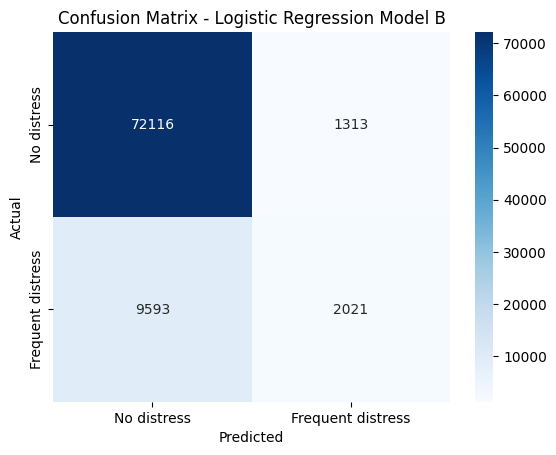

In [30]:
cm = confusion_matrix(y_B_test, y_B_pred_lg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No distress', 'Frequent distress'],
            yticklabels=['No distress', 'Frequent distress'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression Model B')
plt.show()

In [ ]:
lg_B_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lg_B_balanced.fit(X_B_train, y_B_train)
y_B_pred_balanced_lg = lg_B_balanced.predict(X_B_test)
print(classification_report(y_B_test, y_B_pred_balanced_lg))

              precision    recall  f1-score   support

         0.0       0.94      0.74      0.83     73429
         1.0       0.30      0.71      0.43     11614

    accuracy                           0.74     85043
   macro avg       0.62      0.73      0.63     85043
weighted avg       0.85      0.74      0.77     85043



In [32]:
print('AUC-ROC Model B (original):', roc_auc_score(y_B_test, y_B_pred_lg))
print('AUC-ROC Model B (balanced):', roc_auc_score(y_B_test, y_B_pred_balanced_lg))

AUC-ROC Model B (original): 0.5780664511482367
AUC-ROC Model B (balanced): 0.7268333214966998


In [36]:
# Random Forest Classifier Model A / includes depression diagnosis

# Instantiate
rf_A = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit
rf_A.fit(X_A_train, y_A_train)

# Predict
y_A_pred_rf = rf_A.predict(X_A_test)

print(classification_report(y_A_test, y_A_pred_rf))

              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93     73429
         1.0       0.63      0.29      0.40     11614

    accuracy                           0.88     85043
   macro avg       0.76      0.63      0.67     85043
weighted avg       0.86      0.88      0.86     85043



In [37]:
# Random Forest Classifier Model A balanced / includes depression diagnosis

# Instantiate
rf_A_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Fit
rf_A_balanced.fit(X_A_train, y_A_train)

# Predict
y_A_pred_rf_balanced = rf_A_balanced.predict(X_A_test)

print(classification_report(y_A_test, y_A_pred_rf_balanced))

              precision    recall  f1-score   support

         0.0       0.89      0.97      0.93     73429
         1.0       0.62      0.27      0.38     11614

    accuracy                           0.88     85043
   macro avg       0.76      0.62      0.65     85043
weighted avg       0.86      0.88      0.86     85043



In [43]:
print('AUC-ROC Model A (original):', roc_auc_score(y_A_test, y_A_pred_rf))
print('AUC-ROC Model A (balanced):', roc_auc_score(y_A_test, y_A_pred_rf_balanced))

AUC-ROC Model A (original): 0.633494707225985
AUC-ROC Model A (balanced): 0.6216795044325789


In [41]:
# Random Forest Classifier Model B / excludes depression diagnosis

# Instantiate
rf_B = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit
rf_B.fit(X_B_train, y_B_train)

# Predict
y_B_pred_rf = rf_B.predict(X_B_test)

print(classification_report(y_B_test, y_B_pred_rf))

              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     73429
         1.0       0.56      0.19      0.28     11614

    accuracy                           0.87     85043
   macro avg       0.72      0.58      0.60     85043
weighted avg       0.84      0.87      0.84     85043



In [42]:
# Random Forest Classifier Model B balanced / excludes depression diagnosis

# Instantiate
rf_B_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Fit
rf_B_balanced.fit(X_B_train, y_B_train)

# Predict
y_B_pred_rf_balanced = rf_B_balanced.predict(X_B_test)

print(classification_report(y_B_test, y_B_pred_rf_balanced))

              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     73429
         1.0       0.53      0.17      0.26     11614

    accuracy                           0.87     85043
   macro avg       0.71      0.57      0.59     85043
weighted avg       0.83      0.87      0.84     85043



In [44]:
print('AUC-ROC Model B (original):', roc_auc_score(y_B_test, y_B_pred_rf))
print('AUC-ROC Model B (balanced):', roc_auc_score(y_B_test, y_B_pred_rf_balanced))

AUC-ROC Model B (original): 0.5823596800225725
AUC-ROC Model B (balanced): 0.5737061084086379


In [45]:
print('AUC-ROC Logistic Regression Model A (original):', roc_auc_score(y_A_test, y_A_pred_lg))
print('AUC-ROC Logistic Regression Model A (balanced):', roc_auc_score(y_A_test, y_A_pred_balanced_lg))

print('AUC-ROC Logistic Regression Model B (original):', roc_auc_score(y_B_test, y_B_pred_lg))
print('AUC-ROC Logistic Regression Model B (balanced):', roc_auc_score(y_B_test, y_B_pred_balanced_lg))

print('AUC-ROC Random Forest Model A (original):', roc_auc_score(y_A_test, y_A_pred_rf))
print('AUC-ROC Random Forest Model A (balanced):', roc_auc_score(y_A_test, y_A_pred_rf_balanced))

print('AUC-ROC Random Forest Model B (original):', roc_auc_score(y_B_test, y_B_pred_rf))
print('AUC-ROC Random Forest Model B (balanced):', roc_auc_score(y_B_test, y_B_pred_rf_balanced))

AUC-ROC Logistic Regression Model A (original): 0.63498263692132
AUC-ROC Logistic Regression Model A (balanced): 0.7591685496052656
AUC-ROC Logistic Regression Model B (original): 0.5780664511482367
AUC-ROC Logistic Regression Model B (balanced): 0.7268333214966998
AUC-ROC Random Forest Model A (original): 0.633494707225985
AUC-ROC Random Forest Model A (balanced): 0.6216795044325789
AUC-ROC Random Forest Model B (original): 0.5823596800225725
AUC-ROC Random Forest Model B (balanced): 0.5737061084086379


| Model | AUC-ROC | Recall (class 1) | Precision (class 1) | F1 (class 1) |
|---|---|---|---|---|
| LR Model A (original) | 0.63 | 0.64 | 0.30 | 0.41 |
| LR Model A (balanced) | 0.76 | 0.35 | 0.73 | 0.48 |
| LR Model B (original) | 0.58 | 0.61 | 0.17 | 0.27 |
| LR Model B (balanced) | 0.73 | 0.30 | 0.71 | 0.43 |
| RF Model A (original) | 0.63 | 0.63 | 0.29 | 0.40 |
| RF Model A (balanced) | 0.62 | 0.62 | 0.27 | 0.38 |
| RF Model B (original) | 0.58 | 0.56 | 0.19 | 0.28 |
| RF Model B (balanced) | 0.57 | 0.53 | 0.17 | 0.26 |



* Takeaway 1 — Model A consistently outperforms Model B across every metric, confirming that depression diagnosis is a powerful predictor. This is consistent with your regression findings too.
* Takeaway 2 — Logistic Regression does better than Random Forest, meaning that the logistic regression model is better at predicting frequent distress than decision tree models. The likely reason is that the relationships in this data are largely linear, which favors Logistic Regression over Random Forest. Worth noting that with hyperparameter tuning Random Forest might improve, but the gap is telling.
* Takeaway 3 — This survey should not be used alone for predicting mental distress individuals.
-   At best, LR Model A (balanced) catches 73% of frequent distress cases — meaning 27% are still missed
-   Precision of 0.35 means many people would be unnecessarily flagged
-   However — the model could still be useful as one input among many in a clinical decision support tool, not as a standalone screener